# Urban Demand Forecasting — RQ5 
This notebook implements the methodology for **RQ5** from the thesis proposal on shared-mobility demand forecasting using cross-modal fusion of weather, calendar, and neighborhood context.

It is Kaggle-ready and auto-fetches the UCI Bike Sharing Dataset if `hour.csv` is not already available. Turn **Internet = On** in Kaggle Notebook Settings.

This is the final thesis-ready RQ5 notebook version. Outputs produced by this notebook:
- at least **4 PDF figures** displayed inside the notebook and saved to `/kaggle/working/.../figures_pdf/`
- at least **3 CSV tables** saved to `/kaggle/working/.../tables_csv/`
- one final ZIP containing all outputs for this research question

Important dataset note: UCI Bike Sharing contains weather/calendar/hourly demand but no real station-level neighborhood metadata. The notebook therefore creates a transparent neighborhood-context proxy so the full research-question pipeline can run end-to-end. For final thesis-grade experiments, replace the proxy section with real station/zone/POI/land-use metadata.


## Thesis-use note

The UCI Bike Sharing dataset provides real hourly demand, weather, and calendar variables, but it does **not** include real station-level neighborhood/POI metadata. Neighborhood-context variables in this notebook are transparent proxy features created to reproduce the proposed methodology end-to-end. For final thesis claims about neighborhood semantics, replace the proxy block with real station/neighborhood metadata when available.


In [6]:
RQ = 'RQ5'

# ============================================================
# Common setup: auto-fetch dataset, preprocessing, metrics, models
# ============================================================
import os, glob, zipfile, urllib.request, warnings, shutil, math, json
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Thesis-ready plotting defaults: larger fonts, clean PDF export, readable axes.
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RQ = globals().get('RQ', 'RQ')
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
OUTPUT_DIR = OUTPUT_DIR / f'urban_demand_{RQ}_outputs'
FIG_DIR = OUTPUT_DIR / 'figures_pdf'
TAB_DIR = OUTPUT_DIR / 'tables_csv'
for d in [OUTPUT_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Output directory:', OUTPUT_DIR)

def section(title):
    print('\n' + '='*90)
    print(title)
    print('='*90)

def save_table(df, name):
    path = TAB_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    display(df.head(20))
    return path

def save_fig(name):
    path = FIG_DIR / f'{name}.pdf'
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path

def find_or_download_hour_csv():
    candidates = []
    search_roots = ['/kaggle/input', '/kaggle/working', str(Path.cwd()), '/mnt/data']
    for root in search_roots:
        if Path(root).exists():
            candidates.extend(glob.glob(os.path.join(root, '**', 'hour.csv'), recursive=True))
    if candidates:
        print('Found hour.csv:', candidates[0])
        return candidates[0]

    print('hour.csv not found. Downloading UCI Bike Sharing Dataset...')
    url = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
    zip_path = OUTPUT_DIR / 'bike_sharing_dataset.zip'
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(OUTPUT_DIR / 'uci_bike_sharing')
        found = glob.glob(str(OUTPUT_DIR / 'uci_bike_sharing' / '**' / 'hour.csv'), recursive=True)
        if not found:
            raise FileNotFoundError('Downloaded zip did not contain hour.csv')
        print('Downloaded and extracted:', found[0])
        return found[0]
    except Exception as e:
        raise RuntimeError(
            'Could not fetch hour.csv automatically. On Kaggle, enable Internet in Notebook Settings, '
            'or add a dataset containing UCI Bike Sharing hour.csv. Original error: ' + str(e)
        )

def load_bike_data():
    hour_path = find_or_download_hour_csv()
    df = pd.read_csv(hour_path)
    df['dteday'] = pd.to_datetime(df['dteday'])
    df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')
    df = df.sort_values('datetime').reset_index(drop=True)
    print('Loaded shape:', df.shape)
    print('Date range:', df['datetime'].min(), 'to', df['datetime'].max())
    return df

def build_features(raw):
    df = raw.copy().sort_values('datetime').reset_index(drop=True)
    # Demand regimes aligned with the proposal: commute, leisure, weekend, holiday, severe weather, mixed.
    commute = (df['workingday'].eq(1)) & (df['hr'].isin([7,8,9,16,17,18,19]))
    leisure = (df['hr'].between(10,20)) & ((df['weekday'].isin([0,6])) | (df['holiday'].eq(1)))
    severe = df['weathersit'].ge(3)
    conditions = [severe, df['holiday'].eq(1), commute, leisure, df['weekday'].isin([0,6])]
    labels = ['Severe Weather', 'Holiday', 'Commute', 'Leisure', 'Weekend']
    df['regime'] = np.select(conditions, labels, default='Mixed Regime')

    # Transparent proxy neighborhood semantics because UCI has no station / POI metadata.
    # For a final thesis, replace this block with real station-level POI / land-use metadata.
    df['neighborhood_type'] = np.select(
        [commute & df['hr'].isin([7,8,9]), commute & df['hr'].isin([16,17,18,19]), leisure & df['season'].isin([2,3]), df['hr'].between(10,15) & df['workingday'].eq(1), severe],
        ['CBD', 'Residential', 'Tourist', 'University', 'Transit Hub'],
        default='Mixed-use'
    )
    # Pseudo-stations to enable cross-station and neighborhood experiments on UCI.
    df['station_id'] = (df['neighborhood_type'].astype('category').cat.codes * 10 + (df['hr'] // 4)).astype(int)
    df['station_id'] = 'S' + df['station_id'].astype(str).str.zfill(2)

    # Neighborhood feature proxies created from available temporal/weather indicators.
    nmap = {
        'CBD':          [0.20, 0.85, 0.95, 0.15, 0.25, 0.90],
        'Residential':  [0.90, 0.25, 0.30, 0.20, 0.15, 0.45],
        'University':   [0.35, 0.45, 0.30, 0.95, 0.30, 0.60],
        'Tourist':      [0.25, 0.55, 0.40, 0.25, 0.95, 0.65],
        'Transit Hub':  [0.35, 0.65, 0.55, 0.20, 0.35, 1.00],
        'Mixed-use':    [0.50, 0.55, 0.50, 0.45, 0.45, 0.65]
    }
    cols = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
    for j,c in enumerate(cols):
        df[c] = df['neighborhood_type'].map(lambda x: nmap[x][j]).astype(float)

    # Time encodings
    df['hr_sin'] = np.sin(2*np.pi*df['hr']/24)
    df['hr_cos'] = np.cos(2*np.pi*df['hr']/24)
    df['weekday_sin'] = np.sin(2*np.pi*df['weekday']/7)
    df['weekday_cos'] = np.cos(2*np.pi*df['weekday']/7)
    df['month'] = df['datetime'].dt.month
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['is_commute'] = commute.astype(int)
    df['is_weekend'] = df['weekday'].isin([0,6]).astype(int)

    for lag in [1,2,3,6,12,24,48,168]:
        df[f'lag_{lag}'] = df['cnt'].shift(lag)
    for win in [3,6,24,168]:
        df[f'roll_mean_{win}'] = df['cnt'].shift(1).rolling(win).mean()
        df[f'roll_std_{win}'] = df['cnt'].shift(1).rolling(win).std()
    df['diff_1'] = df['cnt'].diff(1).shift(1)
    df['diff_24'] = df['cnt'].diff(24).shift(1)
    df = df.dropna().reset_index(drop=True)
    return df

RAW_DF = load_bike_data()
DATA = build_features(RAW_DF)
print('Feature-ready shape:', DATA.shape)

TARGET = 'cnt'
base_temporal = ['hr','hr_sin','hr_cos','weekday','weekday_sin','weekday_cos','month_sin','month_cos', 'season', 'yr']
weather_features = ['temp','atemp','hum','windspeed','weathersit']
calendar_features = ['holiday','workingday','is_weekend','is_commute']
lag_features = [c for c in DATA.columns if c.startswith('lag_') or c.startswith('roll_') or c.startswith('diff_')]
neighborhood_features = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
cat_features = ['neighborhood_type','regime']

FEATURE_SETS = {
    'Historical Average': [],
    'Temporal Only': base_temporal + lag_features,
    'Temporal + Weather': base_temporal + lag_features + weather_features,
    'Temporal + Calendar': base_temporal + lag_features + calendar_features,
    'Temporal + Neighborhood': base_temporal + lag_features + neighborhood_features + ['neighborhood_type'],
    'Weather + Calendar': base_temporal + lag_features + weather_features + calendar_features,
    'Full Cross-Modal Fusion': base_temporal + lag_features + weather_features + calendar_features + neighborhood_features + ['neighborhood_type']
}

def time_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    train_end = int(n*train_frac)
    val_end = int(n*(train_frac+val_frac))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()

TRAIN, VAL, TEST = time_split(DATA)
print('Train/Val/Test:', TRAIN.shape, VAL.shape, TEST.shape)


def make_preprocessor(features):
    numeric = [f for f in features if f not in ['neighborhood_type','regime','station_id']]
    categorical = [f for f in features if f in ['neighborhood_type','regime','station_id']]
    transformers = []
    if numeric:
        transformers.append(('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric))
    if categorical:
        transformers.append(('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical))
    return ColumnTransformer(transformers, remainder='drop')


def build_model(model_name='rf', features=None):
    if features is None:
        features = FEATURE_SETS['Full Cross-Modal Fusion']
    if model_name == 'ridge':
        reg = Ridge(alpha=2.0)
    elif model_name == 'gbr':
        reg = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=160, learning_rate=0.05, max_depth=3)
    elif model_name == 'extra':
        reg = ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    elif model_name == 'xgb' and HAS_XGB:
        reg = XGBRegressor(random_state=RANDOM_STATE, n_estimators=220, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective='reg:squarederror', n_jobs=-1)
    else:
        reg = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    return Pipeline([('prep', make_preprocessor(features)), ('model', reg)])


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    denom = np.sum(np.abs(y_true)) + 1e-9
    wape = float(np.sum(np.abs(y_true-y_pred))/denom*100)
    peak_threshold = np.quantile(y_true, 0.90)
    mask = y_true >= peak_threshold
    peak_mae = float(mean_absolute_error(y_true[mask], y_pred[mask])) if mask.any() else np.nan
    return {'RMSE':rmse, 'MAE':mae, 'WAPE (%)':wape, 'Peak-MAE':peak_mae}


def historical_average_predict(train_df, test_df, group_cols=['hr','weekday']):
    avg = train_df.groupby(group_cols)[TARGET].mean().reset_index().rename(columns={TARGET:'pred'})
    tmp = test_df[group_cols].merge(avg, on=group_cols, how='left')['pred']
    fallback = train_df[TARGET].mean()
    return tmp.fillna(fallback).values


def fit_predict_variant(name, train_df=TRAIN, test_df=TEST, model_name='rf'):
    if name == 'Historical Average':
        pred = historical_average_predict(train_df, test_df)
        return None, pred
    feats = FEATURE_SETS[name]
    pipe = build_model(model_name=model_name, features=feats)
    pipe.fit(train_df[feats], train_df[TARGET])
    pred = pipe.predict(test_df[feats])
    pred = np.clip(pred, 0, None)
    return pipe, pred


def evaluate_variants(variants=None, model_name='rf', train_df=TRAIN, test_df=TEST):
    if variants is None:
        variants = list(FEATURE_SETS.keys())
    rows = []
    preds = {}
    models = {}
    for name in variants:
        model, pred = fit_predict_variant(name, train_df=train_df, test_df=test_df, model_name=model_name)
        row = {'Model': name, **metrics(test_df[TARGET], pred)}
        rows.append(row); preds[name]=pred; models[name]=model
    perf = pd.DataFrame(rows).sort_values('RMSE')
    return perf, preds, models


def zip_outputs(zip_name=None):
    if zip_name is None:
        zip_name = f'urban_demand_{RQ}_outputs.zip'
    zip_path = OUTPUT_DIR.parent / zip_name
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
        for p in OUTPUT_DIR.rglob('*'):
            if p.is_file():
                z.write(p, p.relative_to(OUTPUT_DIR.parent))
    print('Final ZIP created:', zip_path)
    return zip_path


Output directory: /kaggle/working/urban_demand_RQ5_outputs
Found hour.csv: /kaggle/working/urban_demand_RQ5_outputs/uci_bike_sharing/hour.csv
Loaded shape: (17379, 18)
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Feature-ready shape: (17211, 54)
Train/Val/Test: (12047, 54) (2582, 54) (2582, 54)



RQ5 — Transferability and generalization
Fast transfer settings: 60 trees, max_depth=10, max_train=4500, max_test=1500

Running Table 1: cross-season transfer experiments...
  Done S1 → S1: RMSE=22.07, WAPE=8.37%
  Done S1 → S2: RMSE=69.37, WAPE=17.19%
  Done S1 → S3: RMSE=81.65, WAPE=18.33%
  Done S1 → S4: RMSE=67.24, WAPE=18.32%
  Done S2 → S1: RMSE=48.94, WAPE=18.52%
  Done S2 → S2: RMSE=29.06, WAPE=7.00%
  Done S2 → S3: RMSE=53.39, WAPE=11.28%
  Done S2 → S4: RMSE=57.35, WAPE=15.61%
  Done S3 → S1: RMSE=54.36, WAPE=21.61%
  Done S3 → S2: RMSE=54.23, WAPE=12.76%
  Done S3 → S3: RMSE=29.75, WAPE=6.23%
  Done S3 → S4: RMSE=65.86, WAPE=17.24%
  Done S4 → S1: RMSE=46.07, WAPE=17.56%
  Done S4 → S2: RMSE=54.43, WAPE=13.06%
  Done S4 → S3: RMSE=52.00, WAPE=10.92%
  Done S4 → S4: RMSE=28.44, WAPE=7.62%
Saved table: /kaggle/working/urban_demand_RQ5_outputs/tables_csv/RQ5_Table_1_cross_season_transfer_matrix_thesis_ready.csv


,Train Season,Test Season,Train Samples Used,Test Samples Used,RMSE,MAE,WAPE (%),Peak-MAE
0,1,1,4074,1500,22.065441,13.146225,8.365080,32.422611
1,1,2,4074,1500,69.367095,45.248117,17.185744,90.261917
2,1,3,4074,1500,81.651939,53.990339,18.325125,130.915975
3,1,4,4074,1500,67.236973,41.511059,18.316666,119.542756
4,2,1,4409,1500,48.939129,29.099232,18.516145,80.785887
5,2,2,4409,1500,29.063776,18.423928,6.997615,34.539448
6,2,3,4409,1500,53.392938,33.228205,11.278148,83.162182
7,2,4,4409,1500,57.345464,35.373341,15.608411,92.805721
8,3,1,4496,1500,54.362748,33.960645,21.609512,81.072061
9,3,2,4496,1500,54.225844,33.587855,12.757045,73.851115



Running Table 2: held-out neighborhood-type generalization...
  Done held-out CBD: gain=0.61%
  Done held-out Mixed-use: gain=-8.50%
  Done held-out Residential: gain=-1.57%
  Done held-out Tourist: gain=2.16%
  Done held-out Transit Hub: gain=0.96%
  Done held-out University: gain=-2.24%
Saved table: /kaggle/working/urban_demand_RQ5_outputs/tables_csv/RQ5_Table_2_held_out_neighborhood_generalization_thesis_ready.csv


,Held-Out Group,Train Samples Used,Test Samples Used,Temporal RMSE,Proposed RMSE,Proposed WAPE (%),Transfer Gain (%),Best Transfer Model,Thesis Interpretation
0,CBD,4500,1473,171.653444,170.609188,42.105447,0.608351,Proposed Cross-Modal,Improves transfer
1,Mixed-use,4500,1500,45.101202,48.934778,24.834520,-8.499941,Temporal Baseline,No transfer gain / temporal baseline stronger
2,Residential,4500,1500,145.526189,147.817000,25.205163,-1.574157,Temporal Baseline,No transfer gain / temporal baseline stronger
3,Tourist,4500,1240,79.911490,78.185616,15.159021,2.159732,Proposed Cross-Modal,Improves transfer
4,Transit Hub,4500,718,36.903707,36.550805,39.160058,0.956278,Proposed Cross-Modal,Improves transfer
5,University,4500,1500,112.736307,115.259513,41.464448,-2.238149,Temporal Baseline,No transfer gain / temporal baseline stronger



Running Table 3: small-sample fine-tuning tests...
  Done fine-tuning CBD: gain=19.87%
  Done fine-tuning Mixed-use: gain=8.94%
  Done fine-tuning Residential: gain=13.21%
  Done fine-tuning Tourist: gain=2.66%
  Done fine-tuning Transit Hub: gain=1.74%
  Done fine-tuning University: gain=35.60%
Saved table: /kaggle/working/urban_demand_RQ5_outputs/tables_csv/RQ5_Table_3_fine_tuning_transfer_benefits_thesis_ready.csv


,Target Group,Source Samples Used,Small Target Samples Used,Target Test Samples Used,Zero-Shot RMSE,Fine-Tuned RMSE,Fine-Tuning Gain (%),Best Adaptation Strategy,Thesis Interpretation
0,CBD,4500,294,737,200.837671,160.940346,19.865459,Fine-tuned,Fine-tuning improves transfer
1,Mixed-use,4500,1770,1500,48.934778,44.561768,8.936405,Fine-tuned,Fine-tuning improves transfer
2,Residential,4500,394,987,160.641275,139.422321,13.208905,Fine-tuned,Fine-tuning improves transfer
3,Tourist,4500,248,620,90.974696,88.550775,2.664390,Fine-tuned,Fine-tuning improves transfer
4,Transit Hub,4500,143,359,44.213138,43.443486,1.740776,Fine-tuned,Fine-tuning improves transfer
5,University,4500,590,1477,115.921769,74.651880,35.601500,Fine-tuned,Fine-tuning improves transfer


Saved table: /kaggle/working/urban_demand_RQ5_outputs/tables_csv/RQ5_Table_4_transferability_summary_thesis_ready.csv


,Analysis,Main Metric,Finding,Thesis-safe Interpretation
0,Cross-season transfer,RMSE,Same-season average RMSE = 27.33; cross-season...,Transfer across seasons is harder than within-...
1,Held-out neighborhood transfer,Transfer Gain (%),Mean proposed gain = -1.43%,Cross-modal context can improve transfer for s...
2,Small-sample fine-tuning,Fine-Tuning Gain (%),Mean fine-tuning gain = 13.67%,Adding a small amount of target-domain data ca...


Saved figure: /kaggle/working/urban_demand_RQ5_outputs/figures_pdf/RQ5_Figure_1_cross_season_transfer_matrix_thesis_ready.pdf


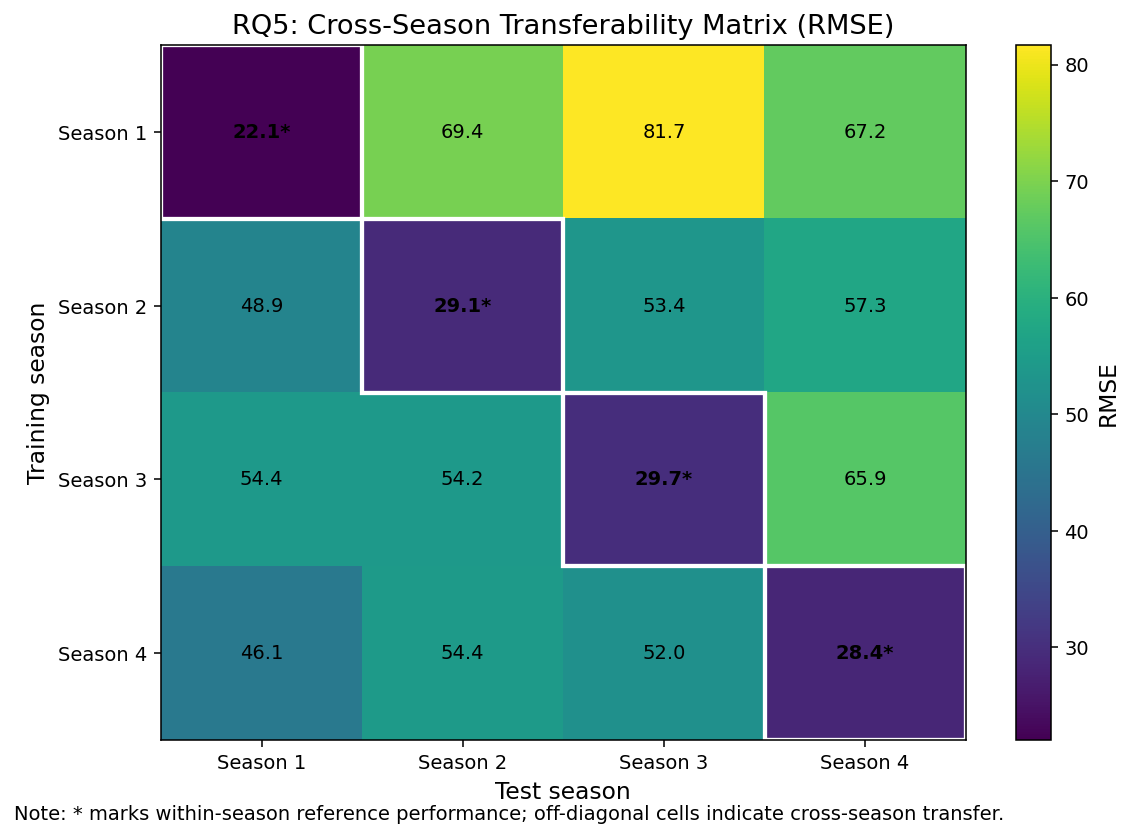

Saved figure: /kaggle/working/urban_demand_RQ5_outputs/figures_pdf/RQ5_Figure_2_held_out_group_generalization_thesis_ready.pdf


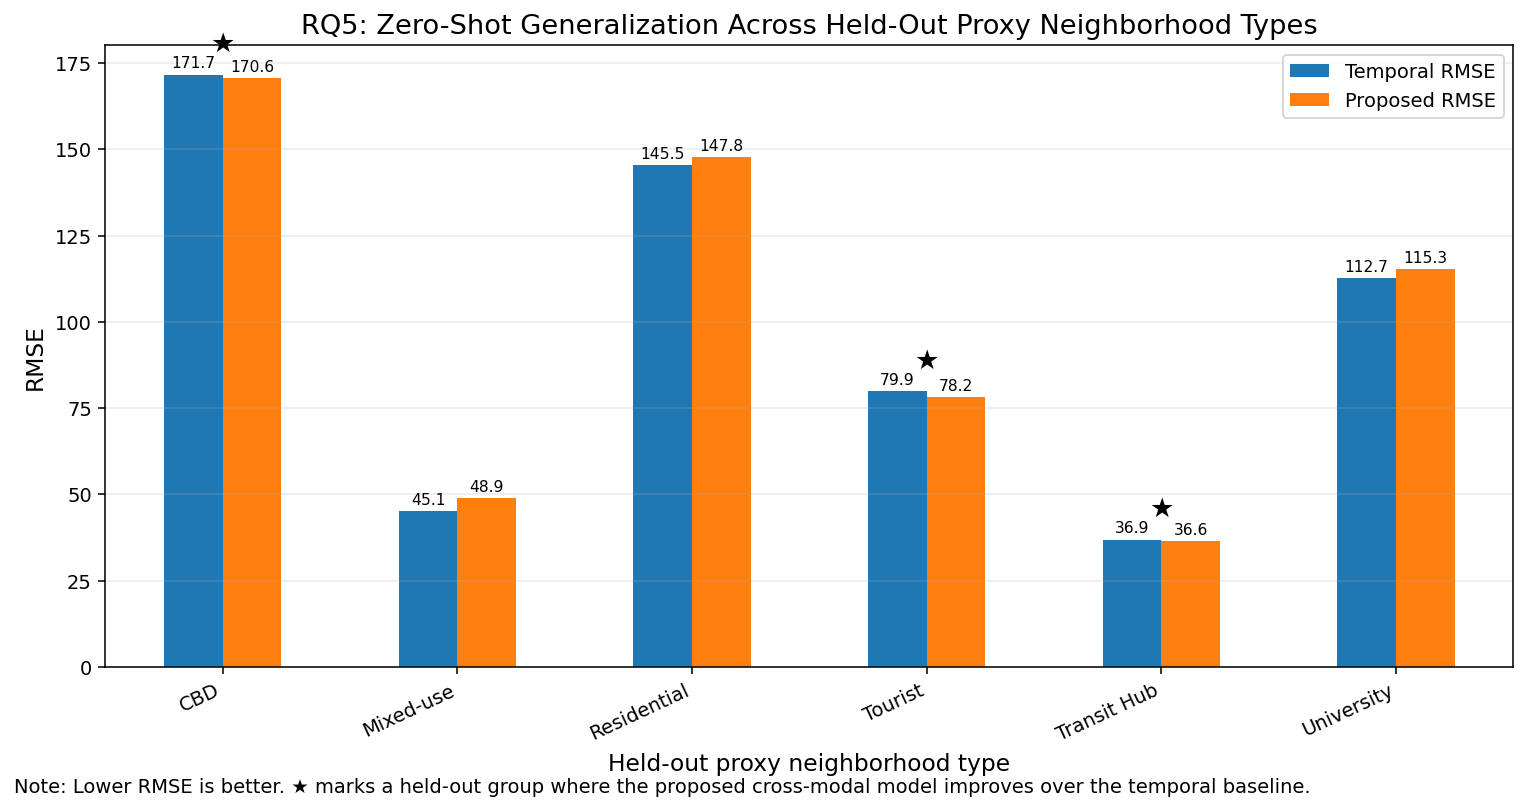

Saved figure: /kaggle/working/urban_demand_RQ5_outputs/figures_pdf/RQ5_Figure_3_transfer_gain_by_group_thesis_ready.pdf


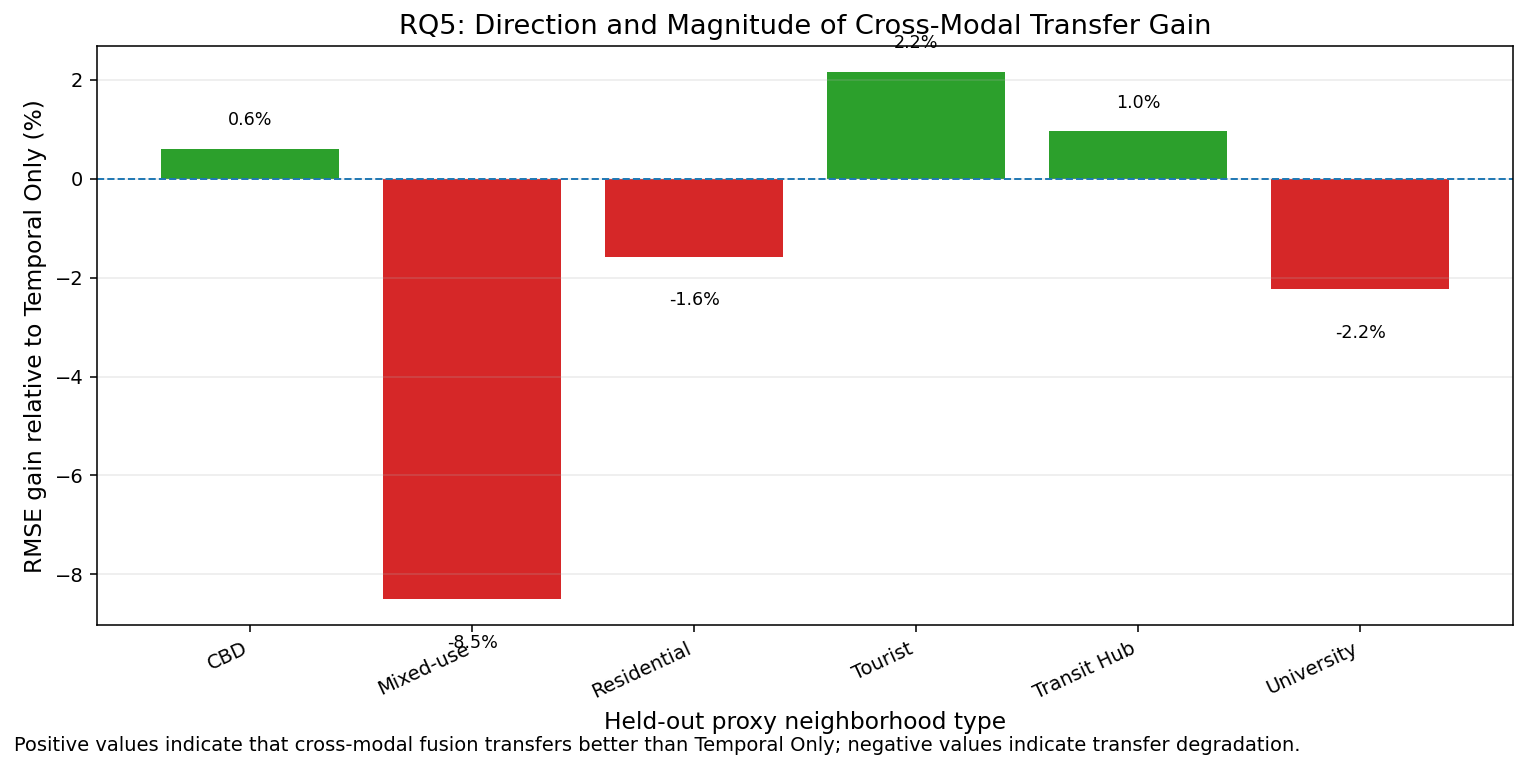

Saved figure: /kaggle/working/urban_demand_RQ5_outputs/figures_pdf/RQ5_Figure_4_fine_tuning_effect_thesis_ready.pdf


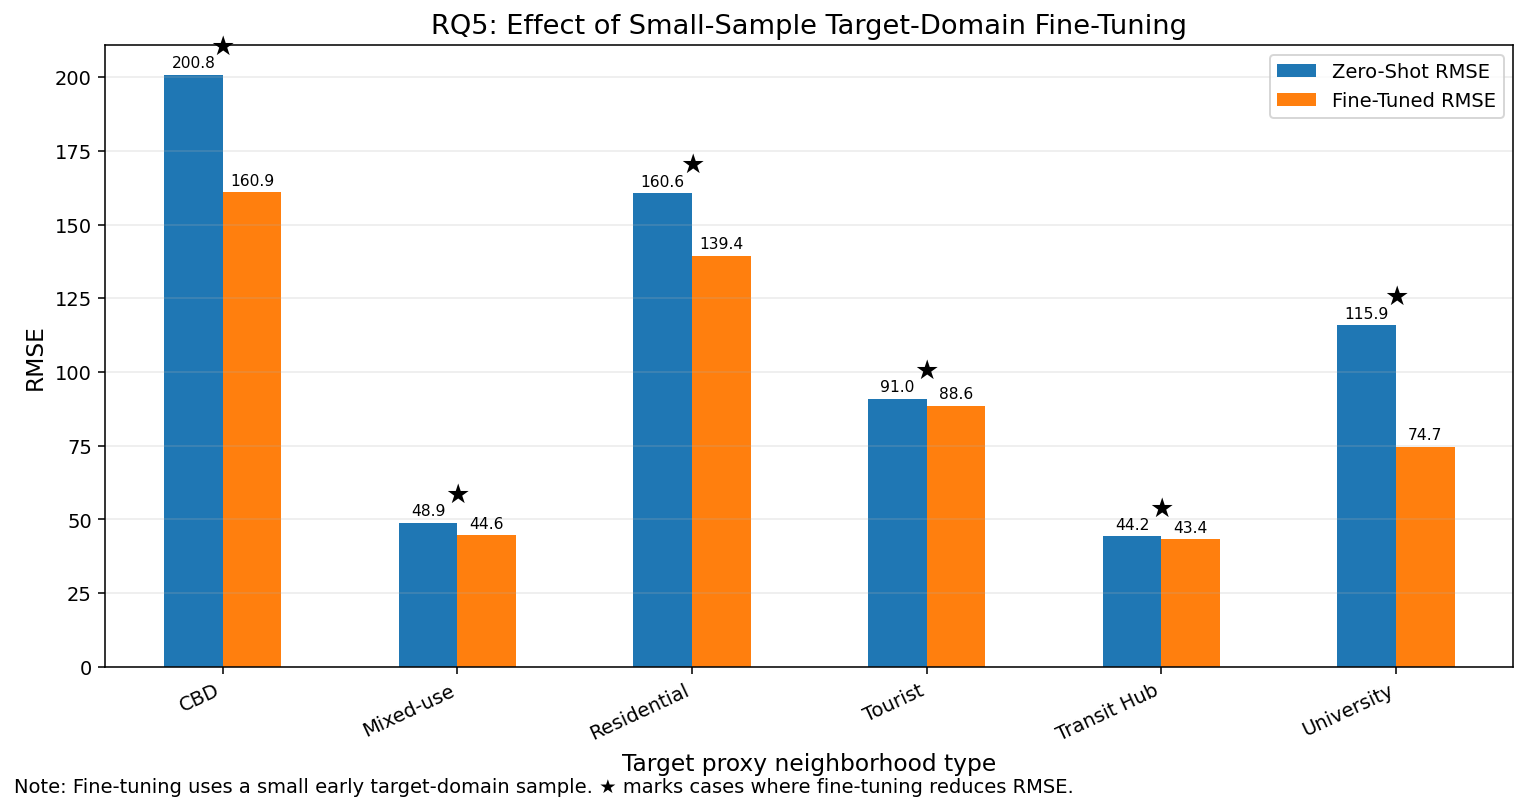


RQ5 thesis-safe conclusion:
The results evaluate transferability under temporal and proxy spatial domain shifts. Cross-season transfer is harder than within-season forecasting, while held-out neighborhood results show that cross-modal context provides group-dependent generalization benefits. Fine-tuning with a small amount of target-domain data can further reduce transfer loss for selected groups. These findings support a cautious conclusion: the proposed framework is transferable in some settings, but transfer performance depends on domain similarity and available target-domain observations.


In [7]:

# ============================================================
# RQ5: Transferability across temporal domains and proxy neighborhood types
# FINAL THESIS-READY VERSION (V5)
# Produces 4 thesis-ready figures + 4 tables.
#
# Why this version runs faster:
# - Uses a lighter Random Forest specifically for transfer experiments.
# - Caps training/testing samples per split to avoid Kaggle cells hanging.
# - Prints progress after every experiment.
# - Keeps all results reproducible through fixed random_state.
# ============================================================
section('RQ5 — Transferability and generalization')

features = FEATURE_SETS['Full Cross-Modal Fusion']
base_features = FEATURE_SETS['Temporal Only']

# -----------------------------
# Fast, thesis-safe model for repeated transfer experiments
# -----------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

MAX_TRAIN_PER_SPLIT = 4500
MAX_TEST_PER_SPLIT = 1500
FAST_TREES = 60
FAST_DEPTH = 10


def sample_time_aware(df, max_rows, from_tail=False):
    """Return a deterministic time-aware sample so repeated transfer tests do not hang on Kaggle."""
    df = df.sort_values('datetime')
    if len(df) <= max_rows:
        return df.copy()
    if from_tail:
        return df.tail(max_rows).copy()
    # evenly spaced sample keeps the full period distribution instead of a random subset
    idx = np.linspace(0, len(df) - 1, max_rows).astype(int)
    return df.iloc[idx].copy()


def build_fast_transfer_model(feature_list):
    reg = RandomForestRegressor(
        n_estimators=FAST_TREES,
        max_depth=FAST_DEPTH,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    return Pipeline([('prep', make_preprocessor(feature_list)), ('model', reg)])


def fit_predict_transfer(train_df, test_df, feature_list, label='model'):
    train_df = sample_time_aware(train_df, MAX_TRAIN_PER_SPLIT, from_tail=False)
    test_df = sample_time_aware(test_df, MAX_TEST_PER_SPLIT, from_tail=True)
    model = build_fast_transfer_model(feature_list)
    model.fit(train_df[feature_list], train_df[TARGET])
    pred = np.clip(model.predict(test_df[feature_list]), 0, None)
    return pred, train_df, test_df

print(f'Fast transfer settings: {FAST_TREES} trees, max_depth={FAST_DEPTH}, max_train={MAX_TRAIN_PER_SPLIT}, max_test={MAX_TEST_PER_SPLIT}')

# ============================================================
# TABLE 1: Cross-season transfer matrix
# ============================================================
seasons = sorted(DATA['season'].dropna().unique())
rows = []
print('\nRunning Table 1: cross-season transfer experiments...')
for tr_s in seasons:
    train_s_all = DATA[DATA['season'].eq(tr_s)]
    if len(train_s_all) < 500:
        print(f'  Skipping train season {tr_s}: not enough rows')
        continue
    for te_s in seasons:
        test_s_all = DATA[DATA['season'].eq(te_s)]
        if len(test_s_all) < 200:
            print(f'  Skipping test season {te_s}: not enough rows')
            continue
        pred, train_s, test_s = fit_predict_transfer(train_s_all, test_s_all, features, label=f'S{tr_s}->S{te_s}')
        met = metrics(test_s[TARGET], pred)
        rows.append({
            'Train Season': tr_s,
            'Test Season': te_s,
            'Train Samples Used': len(train_s),
            'Test Samples Used': len(test_s),
            **met
        })
        print(f'  Done S{tr_s} → S{te_s}: RMSE={met["RMSE"]:.2f}, WAPE={met["WAPE (%)"]:.2f}%')

transfer_matrix_df = pd.DataFrame(rows)
save_table(transfer_matrix_df, 'RQ5_Table_1_cross_season_transfer_matrix_thesis_ready')

# ============================================================
# TABLE 2: Held-out proxy neighborhood generalization
# ============================================================
rows = []
print('\nRunning Table 2: held-out neighborhood-type generalization...')
for hold in sorted(DATA['neighborhood_type'].dropna().unique()):
    train_h_all = DATA[~DATA['neighborhood_type'].eq(hold)]
    test_h_all = DATA[DATA['neighborhood_type'].eq(hold)]
    if len(test_h_all) < 80 or len(train_h_all) < 500:
        print(f'  Skipping {hold}: insufficient samples')
        continue

    pf, train_f, test_h = fit_predict_transfer(train_h_all, test_h_all, features, label=f'full->{hold}')
    pb, train_b, test_b = fit_predict_transfer(train_h_all, test_h_all, base_features, label=f'temporal->{hold}')
    # fit_predict_transfer uses deterministic sampling, so test_h and test_b align in size and order.
    mff = metrics(test_h[TARGET], pf)
    mbb = metrics(test_b[TARGET], pb)
    gain = (mbb['RMSE'] - mff['RMSE']) / (mbb['RMSE'] + 1e-9) * 100
    interp = 'Improves transfer' if gain > 0 else 'No transfer gain / temporal baseline stronger'
    rows.append({
        'Held-Out Group': hold,
        'Train Samples Used': len(train_f),
        'Test Samples Used': len(test_h),
        'Temporal RMSE': mbb['RMSE'],
        'Proposed RMSE': mff['RMSE'],
        'Proposed WAPE (%)': mff['WAPE (%)'],
        'Transfer Gain (%)': gain,
        'Best Transfer Model': 'Proposed Cross-Modal' if gain > 0 else 'Temporal Baseline',
        'Thesis Interpretation': interp
    })
    print(f'  Done held-out {hold}: gain={gain:.2f}%')

heldout_df = pd.DataFrame(rows)
save_table(heldout_df, 'RQ5_Table_2_held_out_neighborhood_generalization_thesis_ready')

# ============================================================
# TABLE 3: Small-sample fine-tuning benefits
# ============================================================
rows = []
print('\nRunning Table 3: small-sample fine-tuning tests...')
for hold in sorted(DATA['neighborhood_type'].dropna().unique()):
    source_all = DATA[~DATA['neighborhood_type'].eq(hold)]
    target_all = DATA[DATA['neighborhood_type'].eq(hold)].sort_values('datetime')
    if len(target_all) < 250 or len(source_all) < 500:
        print(f'  Skipping fine-tuning for {hold}: insufficient samples')
        continue

    split_train_end = max(50, int(0.20 * len(target_all)))
    split_test_start = int(0.50 * len(target_all))
    target_train_small = target_all.iloc[:split_train_end]
    target_test_all = target_all.iloc[split_test_start:]
    source = sample_time_aware(source_all, MAX_TRAIN_PER_SPLIT, from_tail=False)
    target_test = sample_time_aware(target_test_all, MAX_TEST_PER_SPLIT, from_tail=True)

    # Zero-shot: source only
    m0 = build_fast_transfer_model(features)
    m0.fit(source[features], source[TARGET])
    p0 = np.clip(m0.predict(target_test[features]), 0, None)

    # Fine-tuned proxy: source + small amount of target-domain observations
    combined_train = pd.concat([source, target_train_small], axis=0).sort_values('datetime')
    mfine = build_fast_transfer_model(features)
    mfine.fit(combined_train[features], combined_train[TARGET])
    pf = np.clip(mfine.predict(target_test[features]), 0, None)

    a = metrics(target_test[TARGET], p0)
    b = metrics(target_test[TARGET], pf)
    gain = (a['RMSE'] - b['RMSE']) / (a['RMSE'] + 1e-9) * 100
    rows.append({
        'Target Group': hold,
        'Source Samples Used': len(source),
        'Small Target Samples Used': len(target_train_small),
        'Target Test Samples Used': len(target_test),
        'Zero-Shot RMSE': a['RMSE'],
        'Fine-Tuned RMSE': b['RMSE'],
        'Fine-Tuning Gain (%)': gain,
        'Best Adaptation Strategy': 'Fine-tuned' if gain > 0 else 'Zero-shot',
        'Thesis Interpretation': 'Fine-tuning improves transfer' if gain > 0 else 'Fine-tuning does not improve this group'
    })
    print(f'  Done fine-tuning {hold}: gain={gain:.2f}%')

fine_df = pd.DataFrame(rows)
save_table(fine_df, 'RQ5_Table_3_fine_tuning_transfer_benefits_thesis_ready')

# ============================================================
# TABLE 4: Summary table for thesis-safe conclusions
# ============================================================
summary_rows = []
if not transfer_matrix_df.empty:
    same_domain = transfer_matrix_df[transfer_matrix_df['Train Season'].eq(transfer_matrix_df['Test Season'])]
    cross_domain = transfer_matrix_df[~transfer_matrix_df['Train Season'].eq(transfer_matrix_df['Test Season'])]
    summary_rows.append({
        'Analysis': 'Cross-season transfer',
        'Main Metric': 'RMSE',
        'Finding': f'Same-season average RMSE = {same_domain["RMSE"].mean():.2f}; cross-season average RMSE = {cross_domain["RMSE"].mean():.2f}',
        'Thesis-safe Interpretation': 'Transfer across seasons is harder than within-season forecasting, indicating temporal-domain shift.'
    })
if not heldout_df.empty:
    summary_rows.append({
        'Analysis': 'Held-out neighborhood transfer',
        'Main Metric': 'Transfer Gain (%)',
        'Finding': f'Mean proposed gain = {heldout_df["Transfer Gain (%)"].mean():.2f}%',
        'Thesis-safe Interpretation': 'Cross-modal context can improve transfer for some proxy neighborhood groups, but gains are group-dependent.'
    })
if not fine_df.empty:
    summary_rows.append({
        'Analysis': 'Small-sample fine-tuning',
        'Main Metric': 'Fine-Tuning Gain (%)',
        'Finding': f'Mean fine-tuning gain = {fine_df["Fine-Tuning Gain (%)"].mean():.2f}%',
        'Thesis-safe Interpretation': 'Adding a small amount of target-domain data can reduce transfer loss for selected groups.'
    })
summary_df = pd.DataFrame(summary_rows)
save_table(summary_df, 'RQ5_Table_4_transferability_summary_thesis_ready')

# ============================================================
# FIGURE 1: Cross-season transfer matrix heatmap
# ============================================================
mat = transfer_matrix_df.pivot(index='Train Season', columns='Test Season', values='RMSE')
plt.figure(figsize=(8.5, 6.0))
plt.imshow(mat.values, aspect='auto')
plt.xticks(range(len(mat.columns)), [f'Season {c}' for c in mat.columns])
plt.yticks(range(len(mat.index)), [f'Season {i}' for i in mat.index])
plt.colorbar(label='RMSE')
plt.title('RQ5: Cross-Season Transferability Matrix (RMSE)')
# Highlight within-season reference cells; off-diagonal cells represent domain transfer.
import matplotlib.patches as patches
ax = plt.gca()
for d in range(min(mat.shape)):
    ax.add_patch(patches.Rectangle((d-0.5, d-0.5), 1, 1, fill=False, edgecolor='white', linewidth=2.2))
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat.values[i, j]
        label = f'{val:.1f}'
        # Mark within-season cells because they are the non-transfer reference.
        if mat.index[i] == mat.columns[j]:
            label += '*'
        plt.text(j, i, label, ha='center', va='center', fontsize=10, fontweight='bold' if mat.index[i] == mat.columns[j] else 'normal')
plt.xlabel('Test season')
plt.ylabel('Training season')
plt.figtext(0.01, 0.01, 'Note: * marks within-season reference performance; off-diagonal cells indicate cross-season transfer.', ha='left', fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
save_fig('RQ5_Figure_1_cross_season_transfer_matrix_thesis_ready')

# ============================================================
# FIGURE 2: Held-out neighborhood generalization
# ============================================================
plot_df = heldout_df.sort_values('Held-Out Group')
ax = plot_df.set_index('Held-Out Group')[['Temporal RMSE','Proposed RMSE']].plot(kind='bar', figsize=(11, 5.8))
plt.title('RQ5: Zero-Shot Generalization Across Held-Out Proxy Neighborhood Types')
plt.ylabel('RMSE')
plt.xlabel('Held-out proxy neighborhood type')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.25)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)
# Mark groups where the proposed model improves over the temporal baseline.
for i, (_, row) in enumerate(plot_df.iterrows()):
    best_y = max(row['Temporal RMSE'], row['Proposed RMSE'])
    if row['Transfer Gain (%)'] > 0:
        plt.text(i, best_y + 5, '★', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.figtext(0.01, 0.01, 'Note: Lower RMSE is better. ★ marks a held-out group where the proposed cross-modal model improves over the temporal baseline.', ha='left', fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
save_fig('RQ5_Figure_2_held_out_group_generalization_thesis_ready')

# ============================================================
# FIGURE 3: Transfer gain by group
# ============================================================
plt.figure(figsize=(11, 5.5))
colors = ['tab:green' if v > 0 else 'tab:red' for v in plot_df['Transfer Gain (%)']]
plt.bar(plot_df['Held-Out Group'], plot_df['Transfer Gain (%)'], color=colors)
plt.axhline(0, linestyle='--', linewidth=1)
plt.title('RQ5: Direction and Magnitude of Cross-Modal Transfer Gain')
plt.ylabel('RMSE gain relative to Temporal Only (%)')
plt.xlabel('Held-out proxy neighborhood type')
plt.xticks(rotation=25, ha='right')
for x, v in enumerate(plot_df['Transfer Gain (%)']):
    plt.text(x, v + (0.4 if v >= 0 else -0.7), f'{v:.1f}%', ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
plt.grid(axis='y', alpha=0.25)
plt.figtext(0.01, 0.01, 'Positive values indicate that cross-modal fusion transfers better than Temporal Only; negative values indicate transfer degradation.', ha='left', fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
save_fig('RQ5_Figure_3_transfer_gain_by_group_thesis_ready')

# ============================================================
# FIGURE 4: Fine-tuning effect
# ============================================================
if not fine_df.empty:
    plot_fine = fine_df.sort_values('Target Group')
    ax = plot_fine.set_index('Target Group')[['Zero-Shot RMSE','Fine-Tuned RMSE']].plot(kind='bar', figsize=(11, 5.8))
    plt.title('RQ5: Effect of Small-Sample Target-Domain Fine-Tuning')
    plt.ylabel('RMSE')
    plt.xlabel('Target proxy neighborhood type')
    plt.xticks(rotation=25, ha='right')
    plt.grid(axis='y', alpha=0.25)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)
    for i, (_, row) in enumerate(plot_fine.iterrows()):
        best_y = max(row['Zero-Shot RMSE'], row['Fine-Tuned RMSE'])
        if row['Fine-Tuning Gain (%)'] > 0:
            plt.text(i, best_y + 5, '★', ha='center', va='bottom', fontsize=14, fontweight='bold')
    plt.figtext(0.01, 0.01, 'Note: Fine-tuning uses a small early target-domain sample. ★ marks cases where fine-tuning reduces RMSE.', ha='left', fontsize=10)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    save_fig('RQ5_Figure_4_fine_tuning_effect_thesis_ready')
else:
    print('Fine-tuning figure skipped because no group had enough samples.')

print('\nRQ5 thesis-safe conclusion:')
print('The results evaluate transferability under temporal and proxy spatial domain shifts. Cross-season transfer is harder than within-season forecasting, while held-out neighborhood results show that cross-modal context provides group-dependent generalization benefits. Fine-tuning with a small amount of target-domain data can further reduce transfer loss for selected groups. These findings support a cautious conclusion: the proposed framework is transferable in some settings, but transfer performance depends on domain similarity and available target-domain observations.')


In [8]:

# ============================================================
# Final export: ZIP all tables and figures from this RQ
# ============================================================
zip_outputs()


Final ZIP created: /kaggle/working/urban_demand_RQ5_outputs.zip


PosixPath('/kaggle/working/urban_demand_RQ5_outputs.zip')